In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from scipy.stats import norm

In [2]:
df = pd.read_csv("../Data/loan_applications_data.csv")

In [3]:
df.head()

,Customer_ID,Age,Income,Loan_Amount,Credit_Score,Loan_Term (months),Default_Status
0,CUST00001,59,117788,111877,624,24,No
1,CUST00002,49,103929,177160,671,24,No
2,CUST00003,35,135704,59697,652,24,No
3,CUST00004,63,46547,26934,772,48,No
4,CUST00005,28,57114,16894,689,36,No


In [4]:
print("Mean Income:", df["Income"].mean())
print("Median Income:", df["Income"].median())
print("Mode Income:", df["Income"].mode()[0])

Mean Income: 54781.889
Median Income: 49318.0
Mode Income: 18000


In [5]:
print("Range of Loan Amount:", df["Loan_Amount"].max() - df["Loan_Amount"].min())
print("Variance of Loan Amount:", df["Loan_Amount"].var())
print("Standard Deviation of Loan Amount:", df["Loan_Amount"].std())

Range of Loan Amount: 245000
Variance of Loan Amount: 1441785454.8614125
Standard Deviation of Loan Amount: 37970.85006766918


In [6]:
print("Probability of Loan Default:", (df["Default_Status"] == "Yes").mean())

Probability of Loan Default: 0.1072


In [7]:
df["Credit_Range"] = pd.cut(
    df["Credit_Score"],
    bins=[0, 599, 699, 799, 850],
    labels=["Below 600", "600-699", "700-799", "800-850"]
)

df[["Credit_Score", "Credit_Range"]].head()

,Credit_Score,Credit_Range
0,624,600-699
1,671,600-699
2,652,600-699
3,772,700-799
4,689,600-699


In [8]:
contingency_table = pd.crosstab(
    df["Default_Status"],
    df["Credit_Range"]
)

print(contingency_table)

Credit_Range    Below 600  600-699  700-799  800-850
Default_Status                                      
No                    539     2074     1572      279
Yes                   122      227      163       24


In [9]:
low_credit = df[df["Credit_Score"] < 600]

conditional_probability = (
    (low_credit["Default_Status"] == "Yes").sum()
    / len(low_credit)
)

print("P(Default | Credit Score < 600):", conditional_probability)

P(Default | Credit Score < 600): 0.18456883509833585


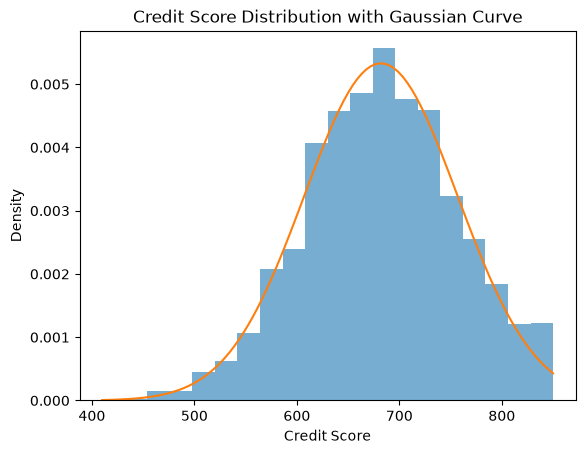

In [11]:
credit_scores = df["Credit_Score"]

mean = credit_scores.mean()
std = credit_scores.std()

plt.hist(credit_scores, bins=20, density=True, alpha=0.6)

x = np.linspace(credit_scores.min(), credit_scores.max(), 100)
y = norm.pdf(x, mean, std)

plt.plot(x, y)

plt.xlabel("Credit Score")
plt.ylabel("Density")
plt.title("Credit Score Distribution with Gaussian Curve")

plt.show()

In [12]:
skewness = df["Loan_Amount"].skew()
kurtosis = df["Loan_Amount"].kurt()

print("Skewness of Loan Amount:", skewness)
print("Kurtosis of Loan Amount:", kurtosis)

Skewness of Loan Amount: 1.5193408797750945
Kurtosis of Loan Amount: 3.2293942287967052


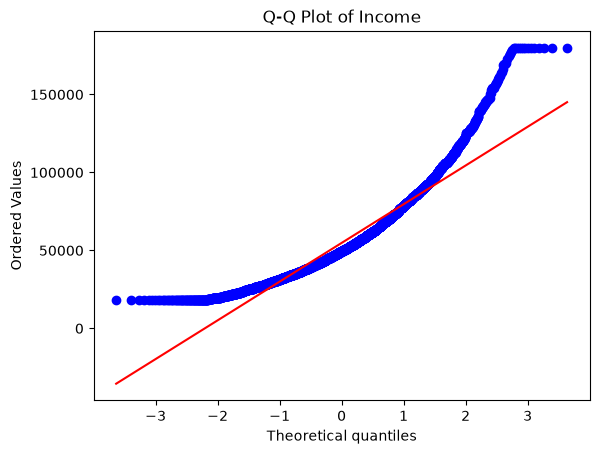

In [15]:
stats.probplot(df["Income"], dist="norm", plot=plt)

plt.title("Q-Q Plot of Income")
plt.show()

In [16]:
vectors = df[["Income", "Loan_Amount"]].head(5).values

print("First 5 customer vectors:")
print(vectors)

First 5 customer vectors:
[[117788 111877]
 [103929 177160]
 [135704  59697]
 [ 46547  26934]
 [ 57114  16894]]


In [17]:
dot_product = np.dot(vectors[0], vectors[1])

print("Dot Product of Customer 1 and Customer 2:", dot_product)

Dot Product of Customer 1 and Customer 2: 32061718372


In [18]:
norm_customer_2 = np.linalg.norm(vectors[1])

print("Norm of Customer 2:", norm_customer_2)

Norm of Customer 2: 205394.50489484862


In [19]:
dot_product = np.dot(vectors[0], vectors[1])

norm_1 = np.linalg.norm(vectors[0])
norm_2 = np.linalg.norm(vectors[1])

cos_angle = dot_product / (norm_1 * norm_2)

angle = np.degrees(np.arccos(cos_angle))

print("Angle between Customer 1 and Customer 2:", angle, "degrees")

Angle between Customer 1 and Customer 2: 16.07676714252828 degrees
